# PhysioNet Challenge 2012 — ICU Mortality Prediction

## Domain context

Early-warning models for in-hospital death are trained on longitudinal ICU vital-sign streams. The PhysioNet Computing in Cardiology Challenge 2012, "Predicting Mortality of ICU Patients," is a clean public dataset for this: 4,000 de-identified ICU patients, each with a 48-hour record of vital signs and a binary in-hospital death outcome (Silva et al., 2012, PhysioNet).

A single patient's measurements (heart rate, blood pressure, temperature, and so on) are sampled irregularly and are strongly autocorrelated within that patient. Across patients there is no causal link at all.

That structure breaks naive k-fold in two ways. The first is patient leakage. If the same patient lands in both train and test, the model sees that patient's future during training and ends up learning who they are rather than how ICU physiology behaves, which lifts AUC for entirely the wrong reason. The second is temporal leakage. Consecutive measurements from one patient are highly autocorrelated, so a 6-hour prediction window lets a training label run into the test period unless that overlap is purged.

`PurgedGroupKFold` handles both. It keeps every patient on one side of the train/test split, then drops training rows whose label horizon reaches into the test window, using the `purge_horizon` and `embargo` parameters.

**Data source:** PhysioNet Challenge 2012, set-a — 4,000 ICU patients, public, no credentialing required.
URL: https://physionet.org/content/challenge-2012/1.0.0/
License: Open Data Commons Attribution License (ODC-By) v1.0

In [1]:
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

import purgedcv
from purgedcv import PurgedGroupKFold, diagnostics

print(f"purged-cross-validation version: {purgedcv.__version__}")

purged-cross-validation version: 0.3.0a0


## Data download and caching

The data downloads once and is cached in `examples/data/` (git-ignored); later runs skip it entirely. The download is about 7 MB (set-a.tar.gz plus Outcomes-a.txt).

In [2]:
# ── Cache directory ────────────────────────────────────────────────────────
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def fetch(url: str, dest_name: str) -> Path:
    dest = DATA_DIR / dest_name
    if dest.exists():
        print(f"Using cached: {dest}")
        return dest
    print(f"Downloading {url} ...")
    req = urllib.request.Request(
        url, headers={"User-Agent": "purged-cross-validation-examples/0.3.0a0"}
    )
    with urllib.request.urlopen(req, timeout=60) as response, open(dest, "wb") as f:
        f.write(response.read())
    print(f"Cached at {dest}")
    return dest


tarball = fetch(
    "https://physionet.org/files/challenge-2012/1.0.0/set-a.tar.gz",
    "set-a.tar.gz",
)
outcomes_path = fetch(
    "https://physionet.org/files/challenge-2012/1.0.0/Outcomes-a.txt",
    "Outcomes-a.txt",
)

Using cached: data/set-a.tar.gz
Using cached: data/Outcomes-a.txt


## Parse patient files and build a wide-format DataFrame

Each patient is a text file with `Time, Parameter, Value` columns. We pivot to wide format and keep the four vital signs that are recorded most consistently (HR for heart rate, SysABP for systolic blood pressure, Temp for temperature, and GCS for the Glasgow Coma Scale), then join the in-hospital mortality label from Outcomes-a.txt.

To keep the notebook quick we subsample 200 of the 4,000 patients, stratified by mortality.

In [3]:
# ── Load outcomes ──────────────────────────────────────────────────────────
outcomes = pd.read_csv(outcomes_path)
outcomes = outcomes[["RecordID", "In-hospital_death"]].rename(
    columns={"In-hospital_death": "mortality"}
)
outcomes["RecordID"] = outcomes["RecordID"].astype(str)

# ── Parse tarball ───────────────────────────────────────────────────────────
VITAL_PARAMS = {"HR", "SysABP", "Temp", "GCS"}

patient_records = []  # list of (record_id, hour, HR, SysABP, Temp, GCS)

with tarfile.open(tarball, "r:gz") as tar:
    for member in tar.getmembers():
        if not member.name.endswith(".txt"):
            continue
        record_id = Path(member.name).stem
        f = tar.extractfile(member)
        if f is None:
            continue
        lines = f.read().decode("utf-8").splitlines()
        # Collect per-hour means for each vital
        hourly: dict[int, dict[str, list[float]]] = {}
        for line in lines[1:]:  # skip header
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            time_str, param, value_str = parts
            if param not in VITAL_PARAMS:
                continue
            try:
                hh, mm = map(int, time_str.split(":"))
                hour = hh
                value = float(value_str)
            except ValueError:
                continue
            hourly.setdefault(hour, {}).setdefault(param, []).append(value)
        # Average each parameter per hour
        for hour, params in hourly.items():
            row = {"record_id": record_id, "hour": hour}
            for p in VITAL_PARAMS:
                vals = params.get(p, [])
                row[p] = float(np.mean(vals)) if vals else np.nan
            patient_records.append(row)

raw = pd.DataFrame(patient_records)
print(f"Raw long-format rows: {raw.shape[0]:,}, unique patients: {raw['record_id'].nunique()}")

Raw long-format rows: 173,620, unique patients: 3937


In [4]:
# ── Join outcomes and filter to patients in outcomes file ──────────────────
raw = raw.merge(outcomes, left_on="record_id", right_on="RecordID", how="inner")
raw = raw.drop(columns=["RecordID"])

print(f"After joining outcomes: {raw['record_id'].nunique()} patients")
print(f"Overall mortality rate: {raw.drop_duplicates('record_id')['mortality'].mean():.1%}")

# ── Stratified subsample of 200 patients ───────────────────────────────────
rng_sample = np.random.default_rng(seed=42)
patients_meta = raw.drop_duplicates("record_id")[["record_id", "mortality"]]

pos = patients_meta[patients_meta["mortality"] == 1]["record_id"].values
neg = patients_meta[patients_meta["mortality"] == 0]["record_id"].values

n_pos = 40  # ~20% mortality, representative of ~24% base rate
n_neg = 160

rng_sample.shuffle(pos)
rng_sample.shuffle(neg)
selected = np.concatenate([pos[:n_pos], neg[:n_neg]])

df = raw[raw["record_id"].isin(selected)].copy()
df = df.sort_values(["record_id", "hour"]).reset_index(drop=True)

# Forward-fill then fill remaining NaNs with column median (per-patient)
for col in ["HR", "SysABP", "Temp", "GCS"]:
    df[col] = df.groupby("record_id")[col].transform(lambda s: s.ffill().bfill())
    df[col] = df[col].fillna(df[col].median())

print(f"\nSubsampled dataset: {df.shape[0]:,} rows, {df['record_id'].nunique()} patients")
print(
    f"Mortality prevalence (subsampled): {df.drop_duplicates('record_id')['mortality'].mean():.1%}"
)
df.head()

After joining outcomes: 3937 patients
Overall mortality rate: 13.9%

Subsampled dataset: 8,732 rows, 200 patients
Mortality prevalence (subsampled): 20.0%


/var/folders/wg/76vqp8252t309qdk15bjgny40000gn/T/ipykernel_82255/310837927.py:18: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng_sample.shuffle(pos)
/var/folders/wg/76vqp8252t309qdk15bjgny40000gn/T/ipykernel_82255/310837927.py:19: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng_sample.shuffle(neg)


,record_id,hour,Temp,HR,SysABP,GCS,mortality
0,132543,0,36.3,76.333333,118.0,15.0,0
1,132543,1,36.3,80.750000,118.0,15.0,0
2,132543,2,36.3,75.333333,118.0,15.0,0
3,132543,3,36.4,73.000000,118.0,15.0,0
4,132543,4,36.4,74.000000,118.0,15.0,0


## Visualising vital-sign patterns by mortality outcome

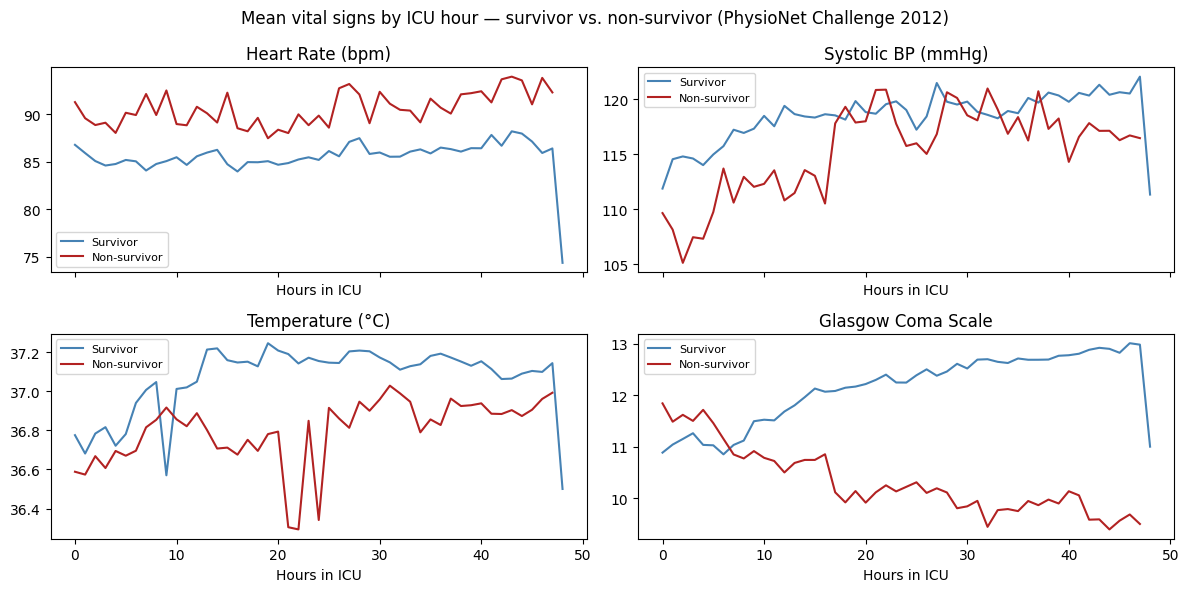

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
fig.suptitle(
    "Mean vital signs by ICU hour — survivor vs. non-survivor (PhysioNet Challenge 2012)",
    fontsize=12,
)

vitals = ["HR", "SysABP", "Temp", "GCS"]
labels_map = {
    "HR": "Heart Rate (bpm)",
    "SysABP": "Systolic BP (mmHg)",
    "Temp": "Temperature (°C)",
    "GCS": "Glasgow Coma Scale",
}

for ax, v in zip(axes.flat, vitals, strict=False):
    for m, label, color in [(0, "Survivor", "steelblue"), (1, "Non-survivor", "firebrick")]:
        sub = df[df["mortality"] == m].groupby("hour")[v].mean()
        ax.plot(sub.index, sub.values, label=label, color=color, lw=1.5)
    ax.set_title(labels_map[v])
    ax.set_xlabel("Hours in ICU")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Setting up prediction and evaluation times

Each row is a prediction event: the model estimates mortality risk from the vital-sign values at that hour. The evaluation time is six hours later, at the end of the prediction window. `PurgedGroupKFold` reads these two timestamps to work out which training rows overlap a test fold and have to be purged.

In [6]:
# ── Build timestamps: hour 0 of patient = 2021-01-01 for this demo ──────────
ICU_ADMIT = pd.Timestamp("2021-01-01 00:00:00")

# Each patient gets a unique baseline so patients don't share time windows
patient_offsets = {
    pid: i * 200  # 200h gap between patients
    for i, pid in enumerate(sorted(df["record_id"].unique()))
}
df["timestamp"] = df.apply(
    lambda row: ICU_ADMIT + pd.Timedelta(hours=patient_offsets[row["record_id"]] + row["hour"]),
    axis=1,
)

LABEL_HORIZON = pd.Timedelta(hours=6)
EMBARGO_WINDOW = pd.Timedelta(hours=2)

prediction_times = df["timestamp"].reset_index(drop=True)
evaluation_times = prediction_times + LABEL_HORIZON

# Convert record_id to integer group label
patient_ids = sorted(df["record_id"].unique())
pid_to_int = {pid: i for i, pid in enumerate(patient_ids)}
groups = df["record_id"].map(pid_to_int).reset_index(drop=True)

FEATURE_COLS = ["HR", "SysABP", "Temp", "GCS"]
X = df[FEATURE_COLS].values
y = df["mortality"].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Groups: {groups.nunique()} unique patients")

X shape: (8732, 4), y shape: (8732,)
Groups: 200 unique patients


## Naive KFold: the wrong approach

Plain `KFold` ignores patient boundaries. One patient's hours land in both train and test, the model leans on that patient's autocorrelation, and the AUC it reports is higher than anything you would actually see on new patients.

In [7]:
kf = KFold(n_splits=4, shuffle=False)
naive_aucs = []

for fold_i, (train_idx, test_idx) in enumerate(kf.split(X)):
    clf = RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1)
    clf.fit(X[train_idx], y[train_idx])
    proba = clf.predict_proba(X[test_idx])[:, 1]
    auc = roc_auc_score(y[test_idx], proba)
    naive_aucs.append(auc)
    print(f"  Naive KFold fold {fold_i + 1}: AUC = {auc:.4f}")

print(f"\nNaive KFold mean AUC: {np.mean(naive_aucs):.4f}")

  Naive KFold fold 1: AUC = 0.6113
  Naive KFold fold 2: AUC = 0.6818


  Naive KFold fold 3: AUC = 0.5632


  Naive KFold fold 4: AUC = 0.6408

Naive KFold mean AUC: 0.6243


## PurgedGroupKFold: the correct approach

`PurgedGroupKFold(n_splits=4, purge_horizon='6h', embargo='2h')` puts each patient wholly in train or wholly in test. Training rows whose 6-hour label window overlaps a test fold's time span are purged, and the 2-hour embargo strips the autocorrelated rows sitting just after each test window.

In [8]:
cv = PurgedGroupKFold(
    n_splits=4,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    groups=groups,
    purge_horizon="6h",
    embargo="2h",
)

temporal_aucs = []
for fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    clf = RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1)
    clf.fit(X[train_idx], y[train_idx])
    proba = clf.predict_proba(X[test_idx])[:, 1]
    auc = roc_auc_score(y[test_idx], proba)
    temporal_aucs.append(auc)

    diagnostics.assert_groups_disjoint(train_idx, test_idx, groups)
    print(
        f"  PurgedGroupKFold fold {fold_i + 1}: AUC = {auc:.4f}  "
        f"(train={len(train_idx)}, test={len(test_idx)}) — groups disjoint ✓"
    )

print(f"\nPurgedGroupKFold mean AUC: {np.mean(temporal_aucs):.4f}")

  PurgedGroupKFold fold 1: AUC = 0.6156  (train=6528, test=2204) — groups disjoint ✓


  PurgedGroupKFold fold 2: AUC = 0.6744  (train=6506, test=2226) — groups disjoint ✓


  PurgedGroupKFold fold 3: AUC = 0.5430  (train=6584, test=2148) — groups disjoint ✓


  PurgedGroupKFold fold 4: AUC = 0.6355  (train=6578, test=2154) — groups disjoint ✓

PurgedGroupKFold mean AUC: 0.6171


## Comparing the two approaches

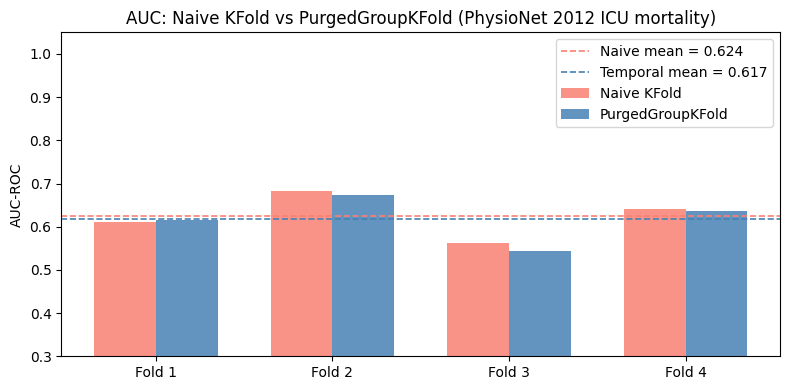

AUC inflation from naive splits: +0.0072 (+0.7 pp)


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f"Fold {i + 1}" for i in range(4)]
x = np.arange(len(folds))
width = 0.35

ax.bar(x - width / 2, naive_aucs, width, label="Naive KFold", color="salmon", alpha=0.85)
ax.bar(x + width / 2, temporal_aucs, width, label="PurgedGroupKFold", color="steelblue", alpha=0.85)

naive_mean = np.nanmean(naive_aucs)
temporal_mean = np.nanmean(temporal_aucs)

ax.axhline(naive_mean, color="salmon", ls="--", lw=1.2, label=f"Naive mean = {naive_mean:.3f}")
ax.axhline(
    temporal_mean, color="steelblue", ls="--", lw=1.2, label=f"Temporal mean = {temporal_mean:.3f}"
)

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0.3, 1.05)
ax.set_title("AUC: Naive KFold vs PurgedGroupKFold (PhysioNet 2012 ICU mortality)")
ax.legend()
plt.tight_layout()
plt.show()

gap = naive_mean - temporal_mean
print(f"AUC inflation from naive splits: {gap:+.4f} ({gap * 100:+.1f} pp)")

## Diagnostics: confirming no group leakage

In [10]:
for _fold_i, (train_idx, test_idx) in enumerate(cv.split(X)):
    diagnostics.assert_groups_disjoint(train_idx, test_idx, groups)

print("All 4 folds passed assert_groups_disjoint — no patient ID appears on both sides.")

All 4 folds passed assert_groups_disjoint — no patient ID appears on both sides.


## Conclusion

For ICU early-warning models, naive k-fold reports AUC that is too high, because the same patients turn up in both training and test.

`PurgedGroupKFold` shuts that down on three fronts at once. Each patient is wholly in train or wholly in test for a given fold. Training rows whose 6-hour label window overlaps the test period are removed. And the 2-hour post-test embargo drops the most autocorrelated residuals. What is left is a score that reflects how the model does on patients it has never seen, which is the only question worth asking before anything reaches a clinical setting.

**Data attribution:** PhysioNet Challenge 2012 (Silva et al., 2012), downloaded from https://physionet.org/content/challenge-2012/1.0.0/ under the ODC-By v1.0 license. The notebook uses the set-a training split (4,000 patients) subsampled to 200.